In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [12]:
data = pd.read_pickle('RFM анализ таблица.pkl')
data

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score_sum,RFM_Score_str,Segment
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,5,7,115,Other
12347.0,2,7,4310.00,5,5,5,15,555,Champion
12348.0,75,4,1797.24,2,4,4,10,244,At Risk
12349.0,19,1,1757.55,4,1,4,9,414,New
12350.0,310,1,334.40,1,1,2,4,112,Lost
...,...,...,...,...,...,...,...,...,...
18280.0,278,1,180.60,1,2,1,4,121,Lost
18281.0,181,1,80.82,1,2,1,4,121,Lost
18282.0,8,2,178.05,5,3,1,9,531,Other


In [13]:
data_RFM = data[['Recency','Frequency','Monetary']]
data_RFM

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [14]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_RFM)
data_scaled

array([[ 2.33457414e+00, -4.25096503e-01,  8.36301037e+00],
       [-9.05340320e-01,  3.54416797e-01,  2.51698905e-01],
       [-1.75359593e-01, -3.53398530e-02, -2.79878269e-02],
       ...,
       [-8.45341904e-01, -2.95177619e-01, -2.08214334e-01],
       [-8.85340848e-01,  1.52368675e+00, -3.51515172e-04],
       [-4.95351144e-01, -1.65258736e-01, -2.35311112e-02]],
      shape=(4338, 3))

In [15]:
inertias = []
K_range = range(2,11)
for k in K_range:
    kmeans = KMeans(n_clusters= k , random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inertias.append(kmeans.inertia_)


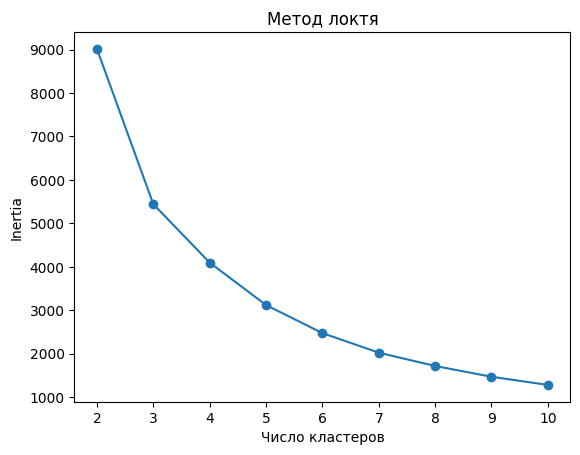

In [17]:
plt.plot(K_range,inertias, marker ='o')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.show()

In [19]:
kmeans = KMeans(n_clusters=4, random_state= 42, n_init=10)
data_RFM['Cluster'] = kmeans.fit_predict(data_scaled)
data_RFM

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1
...,...,...,...,...
18280.0,278,1,180.60,1
18281.0,181,1,80.82,1
18282.0,8,2,178.05,0


In [20]:
cluster_profile = data_RFM.groupby('Cluster').agg(
    Recency1 = ('Recency', 'mean'),
    Frequency1 = ('Frequency', 'mean'),
    Monetary1 = ('Monetary','mean'),
    Count = ('Recency','count')
)
cluster_profile

,Recency1,Frequency1,Monetary1,Count
Cluster,,,,
0,43.702685,3.682711,1353.625312,3054
1,248.075914,1.552015,478.848773,1067
2,7.384615,82.538462,127187.959231,13
3,15.500000,22.333333,12690.500392,204


In [21]:
cluster_name = {
    0: 'Основная масса',
    1: 'Потерянные клиенты',
    2: 'VIP клиенты',
    3:'Чемпионы'
}
data_RFM['Cluster_name'] = data_RFM['Cluster'].map(cluster_name)
data_RFM

,Recency,Frequency,Monetary,Cluster,Cluster_name
CustomerID,,,,,
12346.0,326,1,77183.60,3,Чемпионы
12347.0,2,7,4310.00,0,Основная масса
12348.0,75,4,1797.24,0,Основная масса
12349.0,19,1,1757.55,0,Основная масса
12350.0,310,1,334.40,1,Потерянные клиенты
...,...,...,...,...,...
18280.0,278,1,180.60,1,Потерянные клиенты
18281.0,181,1,80.82,1,Потерянные клиенты
18282.0,8,2,178.05,0,Основная масса


In [25]:
pd.crosstab(data['Segment'],data_RFM['Cluster_name'])

Cluster_name,VIP клиенты,Основная масса,Потерянные клиенты,Чемпионы
Segment,,,,
At Risk,0,127,37,4
Champion,10,187,0,150
Lost,0,180,641,0
Loyal,0,533,13,1
New,0,319,0,0
Other,3,1519,376,49
Potential,0,189,0,0
